In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# https://www.kaggle.com/datasets/imtkaggleteam/breast-cancer

In [ ]:
df=pd.read_csv('breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.shape

(569, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# Data preprocessing

In [ ]:
df.diagnosis.nunique()

2

In [ ]:
df.diagnosis.unique()     #Diagnosis (M = malignant, B = benign)

array(['M', 'B'], dtype=object)

In [ ]:
df.diagnosis.value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


<Axes: >

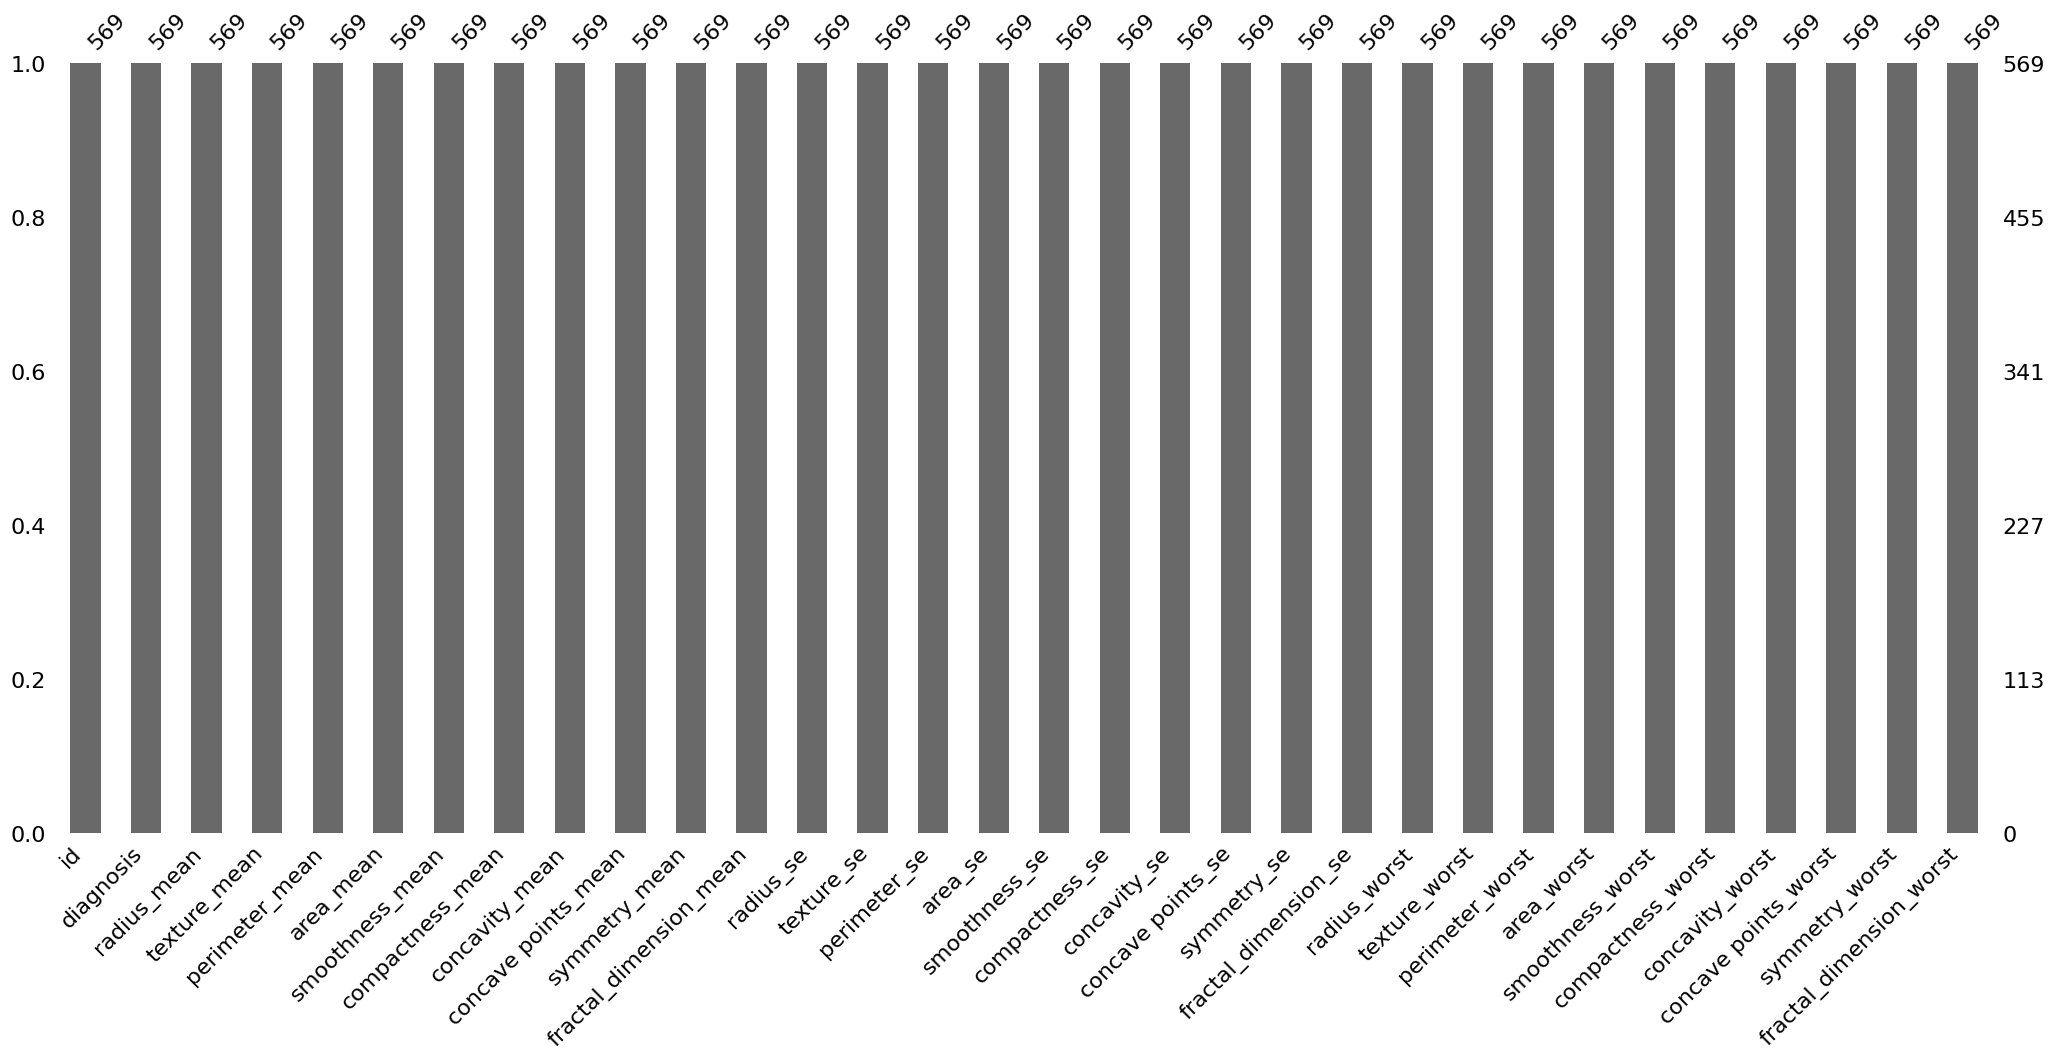

In [ ]:
msno.bar(df)

In [ ]:
#there is no missing value in dataset

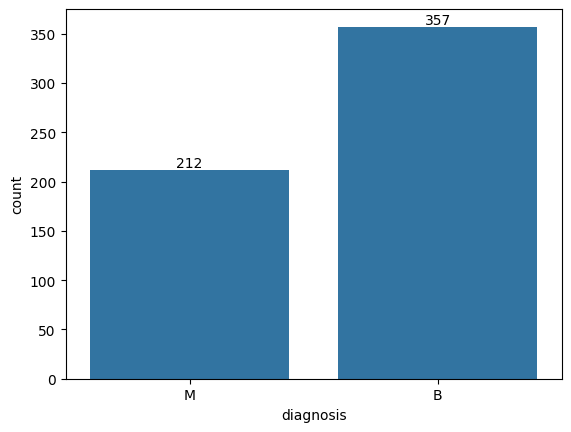

In [ ]:
ax=sns.countplot(x='diagnosis', data=df)
for i in ax.containers:
    ax.bar_label(i)
plt.show()

# EDA

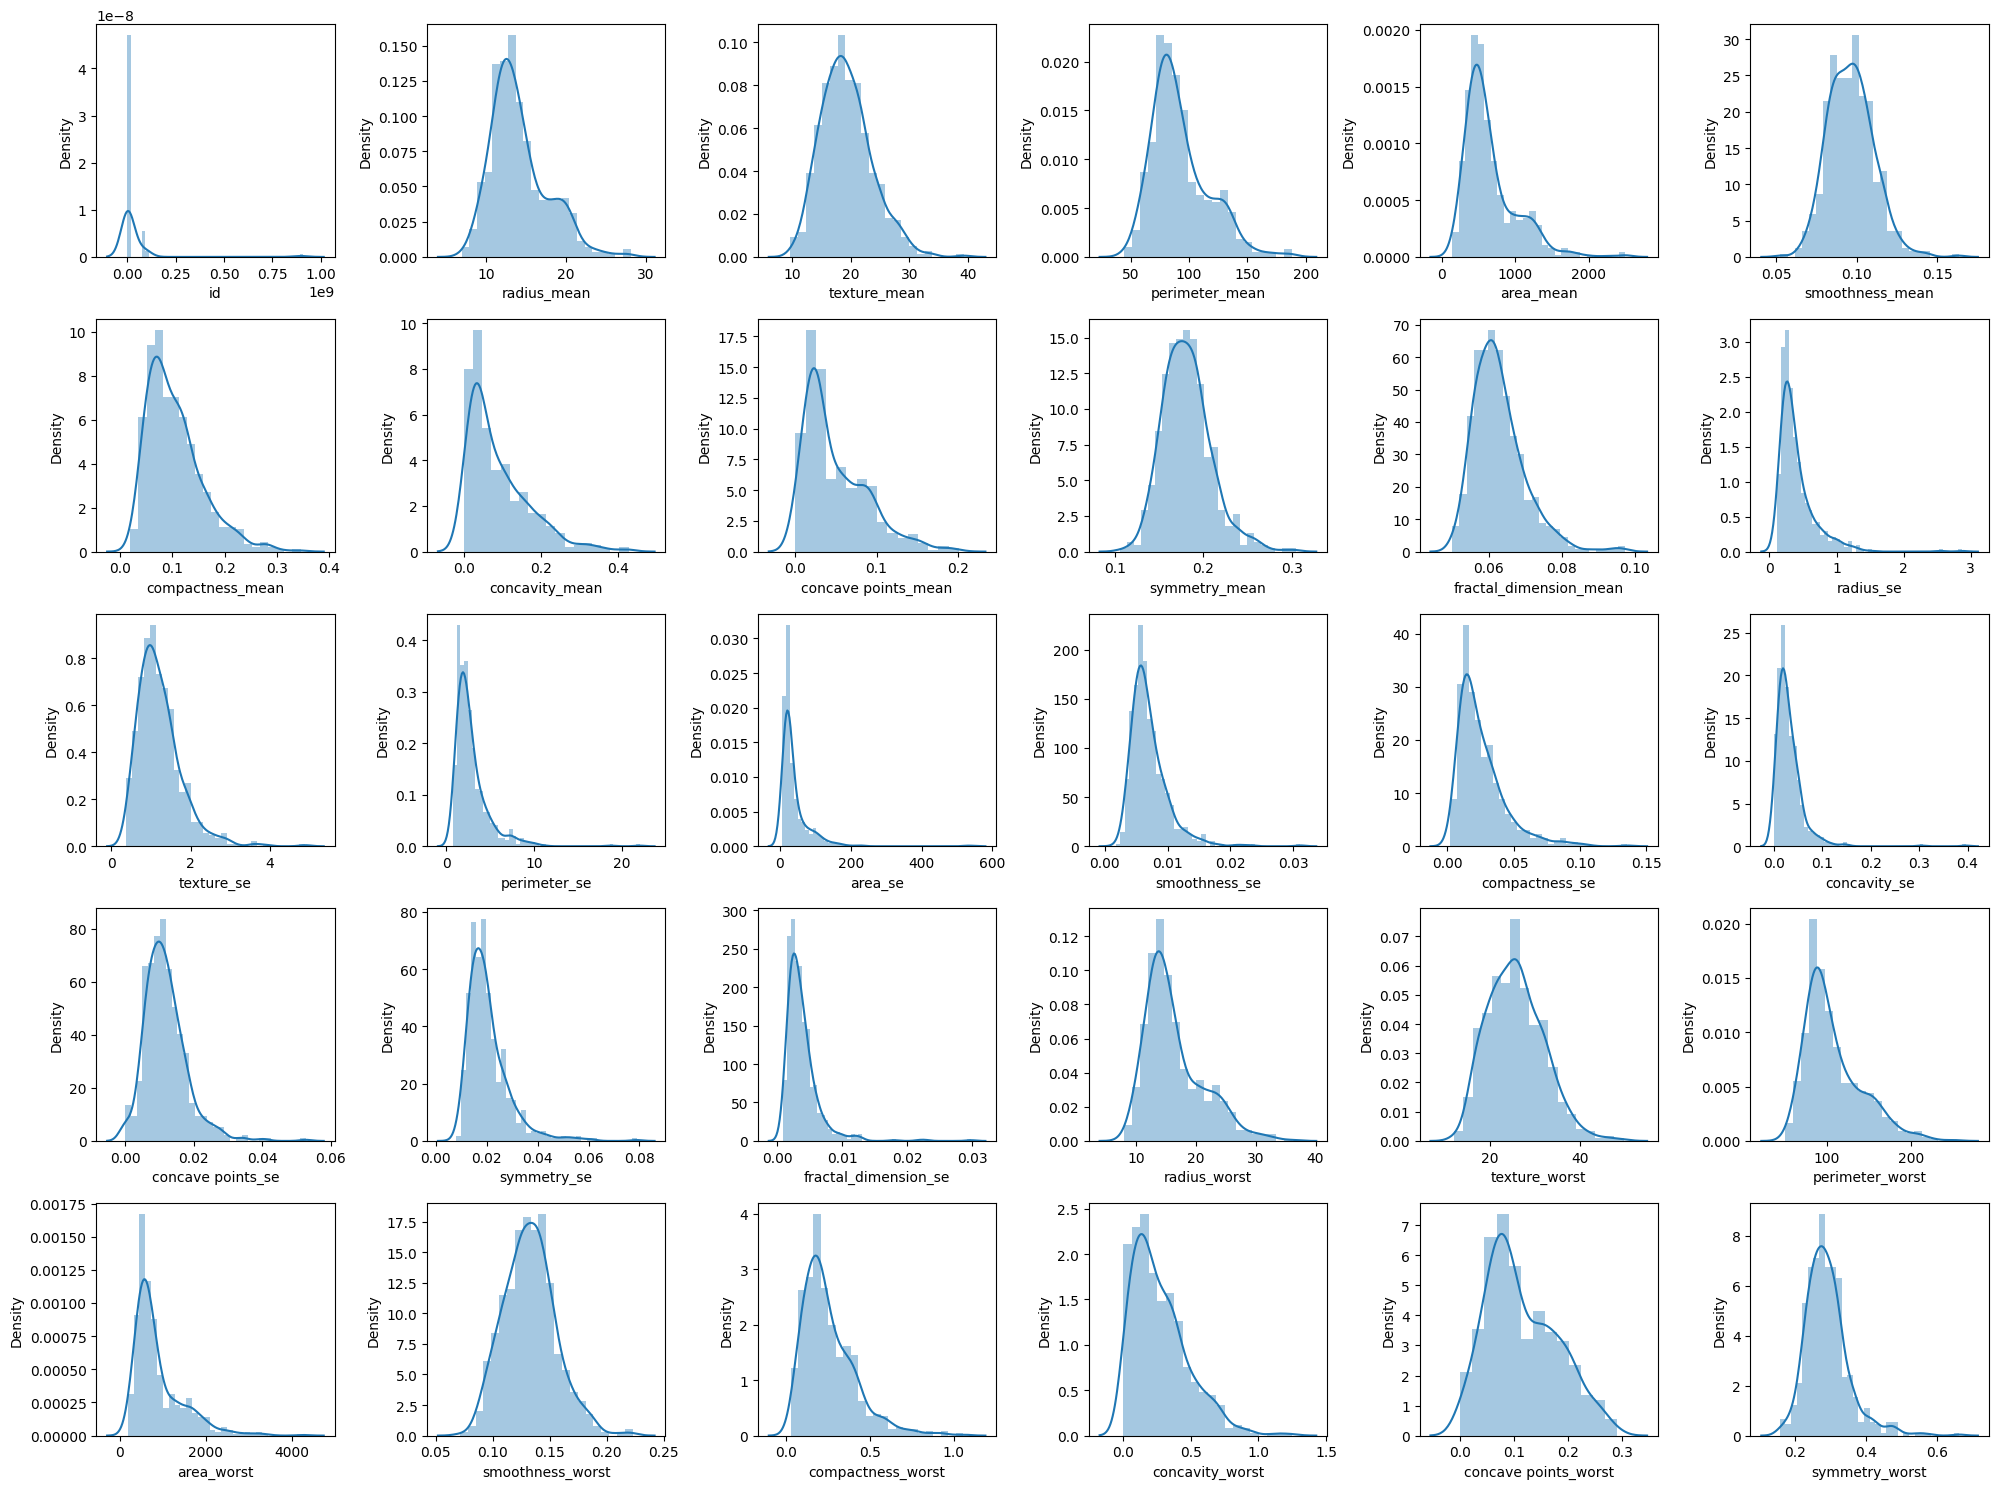

In [ ]:
plt.figure(figsize=(20,15))
plotno=1
for i in df.select_dtypes(include=['number']):
    if plotno<=30:
        ax=plt.subplot(5,6,plotno)
        sns.distplot(df[i])
        plt.xlabel(i)
    plotno+=1

plt.tight_layout()
plt.show()

In [ ]:
df['diagnosis'] = df['diagnosis'].apply(lambda x:1 if x=='M' else 0)

In [ ]:
df.corr()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


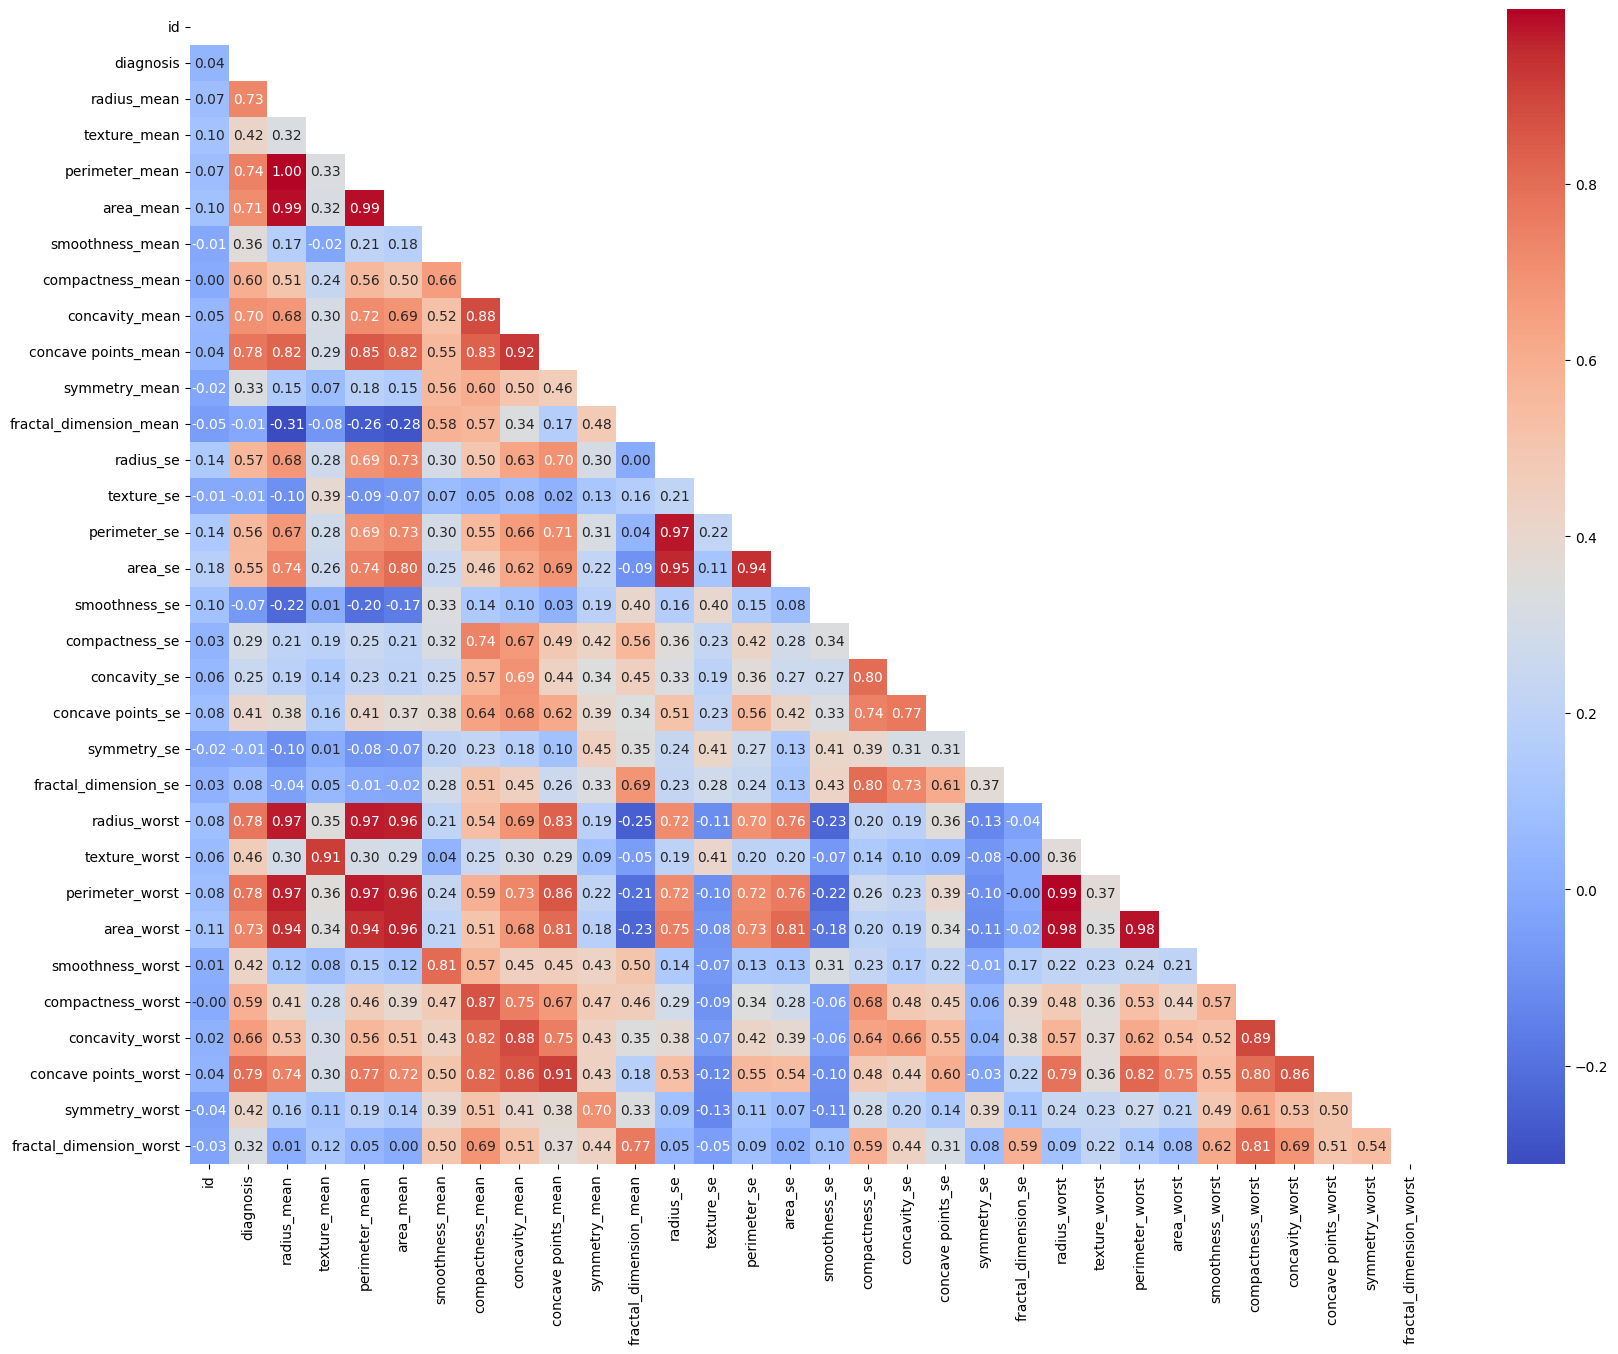

In [ ]:

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20,15))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.show()

In [ ]:
# highly correlated feature causes multicollinearity therefore we have to remove them for good model.
#VIF variance inflation factor

In [ ]:
# feature selection
corr_matrix = df.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)
to_drop = [x for x in tri_df.columns if any(tri_df[x]>0.92)]
df = df.drop(to_drop, axis=1)

print(df.shape[1])

24


In [ ]:
print(len(to_drop))
print(to_drop)

8
['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst']


In [ ]:
df.drop('id',axis=1,inplace=True)

In [ ]:
X=df.drop('diagnosis',axis=True)
y=df['diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=.2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# machine learning algo

In [44]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [45]:
from sklearn.metrics import confusion_matrix,recall_score,f1_score,accuracy_score,precision_score,classification_report

In [46]:
cm=confusion_matrix(y_test,y_pred)
logi_ac=accuracy_score(y_test,y_pred)
pc=precision_score(y_test,y_pred)
rc=recall_score(y_test,y_pred)
print('confusion_matrix',cm)
print('accuracy_score',logi_ac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred))

confusion_matrix [[66  1]
 [ 3 44]]
accuracy_score 0.9649122807017544
precision_score 0.9777777777777777
recall_score 0.9361702127659575
classification_report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.98      0.94      0.96        47

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [47]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors= 5)
model_knn.fit(X_train,y_train)
y_pred_knn=model_knn.predict(X_test)

In [49]:
cm=confusion_matrix(y_test,y_pred_knn)
knn_testingac=accuracy_score(y_test,y_pred_knn)
Trainingac=accuracy_score(y_train,model_knn.predict(X_train))
pc=precision_score(y_test,y_pred_knn)
rc=recall_score(y_test,y_pred_knn)
print('confusion_matrix',cm)
print('testing accuracy_score',knn_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_knn))

confusion_matrix [[66  1]
 [ 4 43]]
testing accuracy_score 0.956140350877193
Training accuracy_score 0.967032967032967
precision_score 0.9772727272727273
recall_score 0.9148936170212766
classification_report
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        67
           1       0.98      0.91      0.95        47

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [50]:
from sklearn.naive_bayes import GaussianNB
model_NB=GaussianNB()
model_NB.fit(X_train,y_train)
y_pred_NB=model_NB.predict(X_test)

In [51]:
cm=confusion_matrix(y_test,y_pred_NB)
nb_testingac=accuracy_score(y_test,y_pred_NB)
Trainingac=accuracy_score(y_train,model_NB.predict(X_train))
pc=precision_score(y_test,y_pred_NB)
rc=recall_score(y_test,y_pred_NB)
print('confusion_matrix',cm)
print('testing accuracy_score',nb_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_NB))

confusion_matrix [[61  6]
 [ 6 41]]
testing accuracy_score 0.8947368421052632
Training accuracy_score 0.9406593406593406
precision_score 0.8723404255319149
recall_score 0.8723404255319149
classification_report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        67
           1       0.87      0.87      0.87        47

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114



In [52]:
# SVC
#Hyperparameter tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc= SVC(probability=True)

parameters = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C':[0.01, 0.05, 0.5, 0.1, 1,10, 15,20]
}
grid = GridSearchCV(svc, parameters)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred_svc = best_model.predict(X_test)

Best Parameters: {'C': 15, 'gamma': 0.01}
Best CV Score: 0.9802197802197803


In [53]:
cm=confusion_matrix(y_test,y_pred_svc)
svc_testingac=accuracy_score(y_test,y_pred_svc)
Trainingac=accuracy_score(y_train,best_model.predict(X_train))
pc=precision_score(y_test,y_pred_svc)
rc=recall_score(y_test,y_pred_svc)
print('confusion_matrix',cm)
print('testing accuracy_score',svc_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_svc))

confusion_matrix [[67  0]
 [ 2 45]]
testing accuracy_score 0.9824561403508771
Training accuracy_score 0.989010989010989
precision_score 1.0
recall_score 0.9574468085106383
classification_report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        67
           1       1.00      0.96      0.98        47

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [54]:
# DT
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

parameters = {
    'criterion':['gini','entropy'],
    'max_depth':range(2,32,1),
    'min_samples_leaf':range(1,10,1),
    'min_samples_split':range(2,10,1),
    'splitter':['best','random']
}

grid_search_dt = GridSearchCV(dtc, parameters, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 32),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10),
                         'splitter': ['best', 'random']},
             verbose=1)

In [ ]:
print("Best Parameters:", grid_search_dt.best_params_)
print("Best CV Score:", grid_search_dt.best_score_)

best_model = grid_search_dt.best_estimator_

y_pred_dt = best_model.predict(X_test)

In [66]:
cm=confusion_matrix(y_test,y_pred_dt)
dt_testingac=accuracy_score(y_test,y_pred_dt)
Trainingac=accuracy_score(y_train,best_model.predict(X_train))
pc=precision_score(y_test,y_pred_dt)
rc=recall_score(y_test,y_pred_dt)
print('confusion_matrix',cm)
print('testing accuracy_score',dt_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_dt))

confusion_matrix [[65  2]
 [ 3 44]]
testing accuracy_score 0.956140350877193
Training accuracy_score 0.9582417582417583
precision_score 0.9565217391304348
recall_score 0.9361702127659575
classification_report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        67
           1       0.96      0.94      0.95        47

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [39]:
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, max_features = 0.5, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rand_clf.fit(X_train, y_train)
y_pred_rf = rand_clf.predict(X_test)


In [65]:
cm=confusion_matrix(y_test,y_pred_rf)
ranf_clf_testingac=accuracy_score(y_test,y_pred_rf)
Trainingac=accuracy_score(y_train,rand_clf.predict(X_train))
pc=precision_score(y_test,y_pred_rf)
rc=recall_score(y_test,y_pred_rf)
print('confusion_matrix',cm)
print('testing accuracy_score',ranf_clf_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_rf))

confusion_matrix [[66  1]
 [ 2 45]]
testing accuracy_score 0.9736842105263158
Training accuracy_score 1.0
precision_score 0.9782608695652174
recall_score 0.9574468085106383
classification_report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        67
           1       0.98      0.96      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gbc = GradientBoostingClassifier(random_state=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train
grid_search_gbc.fit(X_train, y_train)

# Best model
best_model = grid_search_gbc.best_estimator_

# Predictions
y_pred_gbc = best_model.predict(X_test)

# Results
print("Best Parameters:", grid_search_gbc.best_params_)
print("Best CV Score:", grid_search_gbc.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9714285714285715


In [64]:
cm=confusion_matrix(y_test,y_pred_gbc)
gbc_testingac=accuracy_score(y_test,y_pred_gbc)
Trainingac=accuracy_score(y_train,best_model.predict(X_train))
pc=precision_score(y_test,y_pred_gbc)
rc=recall_score(y_test,y_pred_gbc)
print('confusion_matrix',cm)
print('testing accuracy_score',gbc_testingac)
print('Training accuracy_score',Trainingac)
print('precision_score',pc)
print('recall_score',rc)
print('classification_report')
print(classification_report(y_test,y_pred_gbc))

confusion_matrix [[66  1]
 [ 2 45]]
testing accuracy_score 0.9736842105263158
Training accuracy_score 0.9582417582417583
precision_score 0.9782608695652174
recall_score 0.9574468085106383
classification_report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        67
           1       0.98      0.96      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.01, max_depth = 5, n_estimators = 180)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=180,
              n_jobs=None, num_parallel_tree=None, ...)

In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, xgb.predict(X_train)))
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(xgb_acc)
y_pred = xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9934065934065934
0.9736842105263158
[[65  2]
 [ 1 46]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        67
           1       0.96      0.98      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [67]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree Classifier','NB', 'Random Forest Classifier', 'Gradient Boosting Classifier', 'XgBoost'],
    'Score': [100*round(logi_ac,4), 100*round(knn_testingac,4), 100*round(svc_testingac,4), 100*round(dt_testingac,4),100*round(nb_testingac,4), 100*round(ranf_clf_testingac,4),
              100*round(gbc_testingac,4), 100*round(xgb_acc,4)]
})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
2,SVM,98.25
7,XgBoost,97.37
6,Gradient Boosting Classifier,97.37
5,Random Forest Classifier,97.37
0,Logistic Regression,96.49
1,KNN,95.61
3,Decision Tree Classifier,95.61
4,NB,89.47


In [68]:
import pickle
model = svc
pickle.dump(model, open("brest_cancer.pkl","wb"))

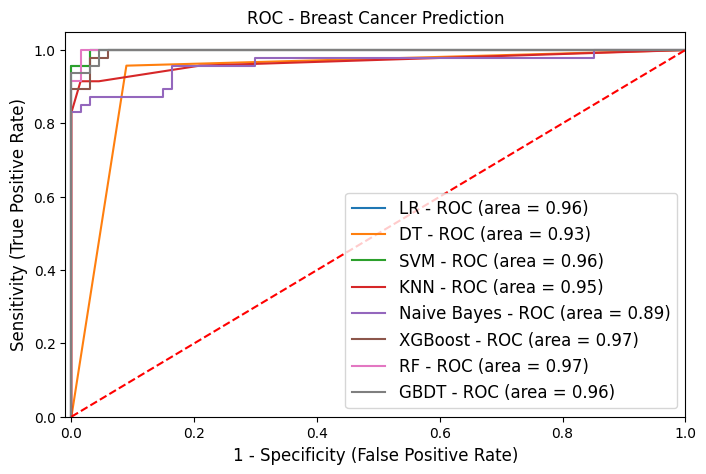

In [69]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': model,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': model_knn,
},
{
    'label': 'Naive Bayes',
    'model': model_NB,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]
for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = metrics.roc_auc_score(y_test,model.predict(X_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Breast Cancer Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

Accuracy: [95.61, 93.86, 96.49, 95.61, 89.47, 97.37, 98.25, 95.61]
ROC-AUC: [np.float64(99.75), np.float64(94.46), np.float64(99.87), np.float64(96.82), np.float64(96.09), np.float64(99.62), np.float64(99.87), np.float64(99.75)]


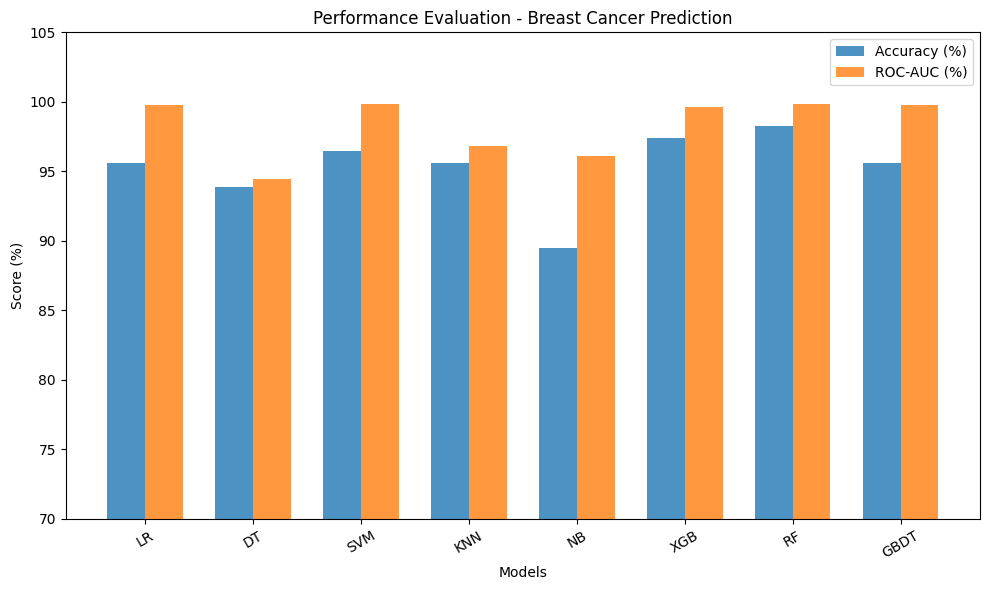

In [72]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Models
models = [
    {'label': 'LR', 'model': model},
    {'label': 'DT', 'model': dtc},
    {'label': 'SVM', 'model': svc},      # SVC(probability=True)
    {'label': 'KNN', 'model': model_knn},
    {'label': 'NB', 'model': model_NB},
    {'label': 'XGB', 'model': xgb},
    {'label': 'RF', 'model': rand_clf},
    {'label': 'GBDT', 'model': gbc}
]

means_accuracy = []
means_roc = []

for m in models:
    clf = m['model']

    # Train model
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # Accuracy
    acc = metrics.accuracy_score(y_test, y_pred) * 100
    means_accuracy.append(round(acc, 2))

    # ROC-AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    roc_auc = metrics.roc_auc_score(y_test, y_prob) * 100
    means_roc.append(round(roc_auc, 2))

print("Accuracy:", means_accuracy)
print("ROC-AUC:", means_roc)

# Plot
n_groups = len(models)
index = np.arange(n_groups)
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

plt.bar(
    index,
    means_accuracy,
    bar_width,
    alpha=0.8,
    label='Accuracy (%)'
)

plt.bar(
    index + bar_width,
    means_roc,
    bar_width,
    alpha=0.8,
    label='ROC-AUC (%)'
)

plt.xlabel('Models')
plt.ylabel('Score (%)')
plt.title('Performance Evaluation - Breast Cancer Prediction')

plt.xticks(
    index + bar_width/2,
    [m['label'] for m in models],
    rotation=30
)

plt.ylim(70, 105)
plt.legend()

plt.tight_layout()
plt.savefig("PE_breast_cancer.jpeg", dpi=400)
plt.show()

In [75]:
import joblib
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

,diagnosis,texture_mean,smoothness_mean,compactness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,...,0.03003,0.006193,17.33,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,...,0.01389,0.003532,23.41,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,...,0.02250,0.004571,25.53,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,...,0.05963,0.009208,26.50,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,...,0.01756,0.005115,16.67,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,22.39,0.11100,0.11590,0.13890,0.1726,0.05623,1.2560,158.70,0.010300,...,0.01114,0.004239,26.40,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,28.25,0.09780,0.10340,0.09791,0.1752,0.05533,2.4630,99.04,0.005769,...,0.01898,0.002498,38.25,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,28.08,0.08455,0.10230,0.05302,0.1590,0.05648,1.0750,48.55,0.005903,...,0.01318,0.003892,34.12,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,29.33,0.11780,0.27700,0.15200,0.2397,0.07016,1.5950,86.22,0.006522,...,0.02324,0.006185,39.42,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
from google.colab import drive
drive.mount('/content/drive')